# Loading pdf files and Vectorize the Conent

In [1]:
from unsloth import FastVisionModel
from pypdf import PdfReader
import os
from tqdm import tqdm
from pymed import PubMed
import json
import pytesseract
from pdf2image import convert_from_path

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [19]:
class PMCDocLoader:
    def __init__(self, data_dir, save_to):
        self.doc_content=[]
        self.data_dir = data_dir
        self.pubmed = PubMed(tool="MyTool", email="qzhao9@lakeheadu.ca")
        self.save_to = save_to
        self.min_words_per_line = 10
        self.pbar = None

    def get_pmc_metadata(self, pmc_ids):
        """
        Query document meta data
        """
        ids = ','.join([id.lstrip('PMC') for id in pmc_ids])
        try:
            results = self.pubmed._get("/entrez/eutils/esummary.fcgi",parameters={'db':'pmc','id':ids,'retmode':'json'})
            meta_result = results['result']
            uuids = meta_result['uids']
            metadata = {}
            for uuid in uuids:
                result = meta_result[uuid]
                authors = ', '.join([d['name'] for d in result['authors']])
                dois = [id['value'] for id in result['articleids'] if id['idtype']=='doi']
                if any(dois):
                    doi = dois[0]
                dois = '; '.join([f"{id['idtype'].upper()}:{id['value']}" for id in result['articleids']])
                cite_nlm = f"{authors}. {result['title']}. {result['source']}. {result['printpubdate']}; {result['volume']}({result['issue']}):{result['pages']}. Epub {result['epubdate']}. {dois}."
                # print(cite_nlm)
                metadata[f'PMC{uuid}'] = {
                                'id':f'PMC{uuid}',
                                'authors':authors,
                                'title': result['title'],
                                'doi':doi,
                                'cite':cite_nlm}
        except Exception as e:
            print('Failed to get meta data, error: ', e)
            return None

        return metadata


    def load(self, load_meta=True, save_output=True, limited_count=None, load_mode='pdf'):
        file_folders = os.listdir(self.data_dir)
        self.doc_content = []
        steps = 200
        file_folders = [folder for folder in file_folders if os.path.isdir(os.path.join(self.data_dir,folder))]
        
        if limited_count:
            file_folders = file_folders[:limited_count]

        self.pbar = tqdm(range(len(file_folders)))    
        load_fun = self.load_pdf_content
        if load_mode == 'ocr':
            load_fun = self.load_pdf_content_ocr

        for i in range(0, len(file_folders), steps):
            batch = file_folders[i:i+steps]
            if load_meta:
                metadata = self.get_pmc_metadata(batch)
            for folder in tqdm(batch):
                try:
                    self.pbar.set_postfix({'Doc':folder})
                    full_path = os.path.join(self.data_dir,folder)
                    files = os.listdir(full_path)
                    num_of_pdf = len([f for f in files if f.endswith('.pdf') ])
                    if num_of_pdf == 0:
                        # print(folder,'No pdf file.')
                        continue

                    nxml_file = [f for f in files if f.endswith('.nxml')]
                    if not any(nxml_file):
                        continue
                    pdf_file = nxml_file[0].replace('.nxml','.pdf')
                    ful_pdf = os.path.join(full_path,pdf_file)
                    if os.path.isfile(ful_pdf):
                        # Load Text Content
                        page_content = load_fun(ful_pdf)

                        # Load Images
                        reader = PdfReader(ful_pdf)
                        pypdf_pages = reader.pages
                        page_imgs = {}
                        for i, page in enumerate(pypdf_pages):
                            if not page.images:
                                continue
                            for img in page.images:
                                # img = img.convert("RGB")
                                img.image.save(os.path.join(full_path,img.name))
                            pil_images = [os.path.join(full_path,img.name) for img in page.images]
                            page_imgs[i] = pil_images

                        if not page_content:
                            continue
                        if load_meta:
                            meta = metadata[folder]
                        else:
                            meta = {'id':folder}
                        meta['content'] = page_content
                        meta['images'] = page_imgs
                        self.doc_content.append(meta)
                except Exception as e:
                    print('Failed to load pdf ', folder)
                    print(e)
                finally:
                    self.pbar.update(1)

        # Save extracted data
        if save_output:
            with open(self.save_to,'w+') as file:
                json.dump(self.doc_content,file)
        self.pbar.close()
        return True

    def load_fulltext(self, save_output=True, limited_count=None):
        file_folders = os.listdir(self.data_dir)
        self.doc_content = []
        steps = 200
        file_folders = [folder for folder in file_folders if os.path.isdir(os.path.join(self.data_dir,folder))]
        
        if limited_count:
            file_folders = file_folders[:limited_count]

        self.pbar = tqdm(range(len(file_folders)))    
        for i in range(0, len(file_folders), steps):
            batch = file_folders[i:i+steps]
           
            for folder in tqdm(batch):
                try:
                    self.pbar.set_postfix({'Doc':folder})
                    full_path = os.path.join(self.data_dir,folder)
                    files = os.listdir(full_path)
                    num_of_pdf = len([f for f in files if f.endswith('.pdf') ])
                    if num_of_pdf == 0:
                        # print(folder,'No pdf file.')
                        continue

                    nxml_file = [f for f in files if f.endswith('.nxml')]
                    if not any(nxml_file):
                        continue
                    pdf_file = nxml_file[0].replace('.nxml','.pdf')
                    ful_pdf = os.path.join(full_path,pdf_file)
                    if os.path.isfile(ful_pdf):
                        # Load Text Content
                        page_content = self.load_pdf_content_ocr(ful_pdf)                     

                        if not page_content:
                            continue
  
                        full_text = {'id':folder}
                        ft = ''
                        for pc in page_content:
                            ft = ' '.join([ft, ' '.join(pc)])
                        full_text['content'] = ft
                        self.doc_content.append(full_text)
                except Exception as e:
                    print('Failed to load pdf ', folder)
                    print(e)
                finally:
                    self.pbar.update(1)

            # Save extracted data
            if save_output:
                with open(self.save_to,'w+') as file:
                    json.dump(self.doc_content,file)
        self.pbar.close()
        return True
    
    def load_pdf_content(self, pdf_file):
        try:
            reader = PdfReader(pdf_file)

            total_pages = len(reader.pages)
            # print('Total Pages:',total_pages)

            # print('Page 1:',page_1.extract_text())
            pages = []
            for p in range(total_pages):
                page = reader.get_page(p)
                page_content = page.extract_text(space_width=250)
                page_content, is_reference = self.post_extract_processing(page_content)
                pages.append(page_content)
                if is_reference:
                    break
        except:
            print('Failed to load ', pdf_file)
            return None

        return pages
    
    def load_pdf_content_ocr(self, pdf_file):
        """
        Read pdf text using OCR.
        """
        try:
            ocr_pages = convert_from_path(pdf_file, 600)

            # print('Pages: ', len(pages))
            # extract text
            pages_text = []
            parent_dir_name = os.path.basename(os.path.dirname(pdf_file))
            for i, p in enumerate(ocr_pages):
                self.pbar.set_postfix({'Doc':parent_dir_name,'Page':f'{i+1}/{len(ocr_pages)}'})
                page_content = pytesseract.image_to_string(p)
                page_content, is_reference = self.post_extract_process_ocr(i, page_content)
                if page_content:
                    pages_text.append(page_content)
                if is_reference:
                    break
        except Exception as e:
            print('Failed to load ', pdf_file, e)
            # raise e
            return None
        return pages_text

    def post_extract_processing(self,page_number, page_content):
        """
        Clean up extracted text
        """
        lines = page_content.split('\n')
        # print(len(lines))
        new_lines = []
        is_reference = False
        start_of_content = False
        for i in range(len(lines)):
            # print(len(lines[i]))
            if new_lines:
                line_1 = new_lines[-1]
            else:
                line_1 = ''
            line_2 = lines[i]
            if page_number == 0 and not start_of_content:
                if not self.is_start_of_text(line_2):
                    continue
                else:
                    start_of_content = True

            if self.is_reference(line_2):
                # print('is_reference: True')
                is_reference = True
                break
            last_of_line_1 = line_1[-1] if line_1 else ''
            if last_of_line_1 in ['-',',',' ',';','"'] or last_of_line_1.isalpha():
                line_1 = line_1[:-1] if line_1[-1] == '-' else line_1
                new_lines[-1] = line_1 +(' ' if last_of_line_1.isalpha else '') +  line_2
            else:
                if not self.is_ignore(line_2):
                    new_lines.append(line_2)
                else:
                    pass
        return new_lines , is_reference #Paragraph
    
    def post_extract_process_ocr(self,page_number, page_content):
        lines = page_content.split('\n')

        if page_number == 0:
            # print(page_content)
            while lines and not self.is_start_of_text(lines[0]):
                lines.pop(0)
            if not lines: # Did not match 'Abstract', then load all.
                lines = page_content.split('\n')
        paragraphs = []
        p = ''
        is_reference = False
        for line in lines:
            if self.is_reference(line):
                is_reference = True
                break
            if line:
                p = p + (' ' if p and p[-1].isalpha() else '') + line
            elif len(p.split()) < self.min_words_per_line:
                p += ' '
            else:# a empty line is the paragraph break
                if not self.is_ignore(p):
                    paragraphs.append(p)
                p = ''
        if p:
            paragraphs.append(p)
        return paragraphs, is_reference

    def is_start_of_text(self,line):
        if line.startswith('Abstract'):
            return True
        
        return False
    
    def is_reference(self, line):
        if line.strip() == 'References':
            return True
        return False
    
    def is_ignore(self,line):
        if not line.strip():
            return True 
        if line.startswith('Acknowledgments') or\
              line.startswith('Conflicts of Interest') or\
              line.startswith('Author Contributions') or\
              line.startswith('Informed Consent Statement') or\
              line.startswith('Data Availability Statement'):
            return True
        # if len(line.strip().split()) < self.min_words_per_line:
        #     return True
        digits=[c for c in line if c.isdigit()]
        if len(digits) / len(line) >= 0.4:
            return True # Most of the charactors are numbers
        
        return False

In [ ]:
data_dir = r'/home/qzhao9/datasets/PMC-Papers/files'
metadata_file = '/home/qzhao9/datasets/metadata.jsonl'

doc_loader = PMCDocLoader(data_dir,metadata_file)

doc_loader.load(load_meta=True, save_output=True, load_mode='ocr', limited_count=0)

print(len(doc_loader.doc_content))


  2%|▏         | 35/1911 [25:50<18:50:52, 36.17s/it, Doc=PMC10651636]

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC9598597/antioxidants-11-01947.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table

Failed to load pdf  PMC9598597
Stream has ended unexpectedly


  5%|▍         | 88/1911 [1:07:02<22:45:30, 44.94s/it, Doc=PMC7428744, Page=12/21] Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(775, 0, 125540027573840)], '/Width': 139, '/Height': 229, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 4, IndirectObject(777, 0, 125540027573840)], '/Width': 123, '/Height': 154, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(779, 0, 125540027573840)], '/Width': 62, '/Height': 121, '/Type': '/XObject'}
Invalid Lookup Table in {'/Subtype': '/Image', '/Filter': '/FlateDecode', '/BitsPerComponent': 8, '/ColorSpace': ['/Indexed', '/DeviceRGB', 5, IndirectObject(775, 0, 125540027573840)], '/Width': 139, '/Heigh

Failed to load pdf  PMC9875997
Invalid object in /Pages


 24%|██▍       | 466/1911 [5:52:24<13:16:36, 33.08s/it, Doc=PMC6421268, Page=16/16] Multiple definitions in dictionary at byte 0x3807a for key /MediaBox
Multiple definitions in dictionary at byte 0x382b4 for key /MediaBox
Multiple definitions in dictionary at byte 0x3854e for key /MediaBox
Multiple definitions in dictionary at byte 0x3874d for key /MediaBox
Multiple definitions in dictionary at byte 0x38944 for key /MediaBox
Multiple definitions in dictionary at byte 0x38bd6 for key /MediaBox
Multiple definitions in dictionary at byte 0x38e20 for key /MediaBox
Multiple definitions in dictionary at byte 0x3908a for key /MediaBox
Multiple definitions in dictionary at byte 0x392dc for key /MediaBox
Multiple definitions in dictionary at byte 0x39546 for key /MediaBox
Multiple definitions in dictionary at byte 0x39740 for key /MediaBox
Multiple definitions in dictionary at byte 0x3998a for key /MediaBox
Multiple definitions in dictionary at byte 0x39c0c for key /MediaBox
Multiple definition

...

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC7331274/12875_2020_Article_1194.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table

Failed to load pdf  PMC7331274
Stream has ended unexpectedly


 97%|█████████▋| 1859/1911 [22:45:57<37:27, 43.22s/it, Doc=PMC9403435]

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC7312994/ijerph-17-03950.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table

Failed to load pdf  PMC7312994
Stream has ended unexpectedly


100%|██████████| 1911/1911 [23:23:59<00:00, 44.08s/it, Doc=PMC9170180, Page=9/9]

1860


In [31]:
data_dir = r'/home/qzhao9/datasets/PMC-Papers/files'
fulltext_file = '/home/qzhao9/datasets/metadata_fulltext.jsonl'

doc_loader = PMCDocLoader(data_dir,fulltext_file)

doc_loader.load_fulltext(save_output=True, limited_count=0)

print(len(doc_loader.doc_content))

  2%|▏         | 35/1911 [25:06<18:28:46, 35.46s/it, Doc=PMC10651636]            

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC9598597/antioxidants-11-01947.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table



 79%|███████▊  | 1504/1911 [18:11:29<4:20:23, 38.39s/it, Doc=PMC8589779]             

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC10343926/molecules-28-05081.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table



 86%|████████▌ | 1646/1911 [19:49:33<1:41:31, 22.99s/it, Doc=PMC10775659]            

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC7331274/12875_2020_Article_1194.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table



 97%|█████████▋| 1859/1911 [22:24:17<26:09, 30.18s/it, Doc=PMC9403435]               

Failed to load  /home/qzhao9/datasets/PMC-Papers/files/PMC7312994/ijerph-17-03950.pdf Unable to get page count.
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't find trailer dictionary
Syntax Error: Couldn't read xref table



100%|██████████| 1911/1911 [23:01:13<00:00, 43.37s/it, Doc=PMC9170180, Page=9/9]

1867


In [8]:
doc_loader.doc_content[0]
# page = doc_loader.load_pdf_content_ocr('/home/qzhao9/datasets/PMC-Papers/files/PMC10122388/12893_2023_Article_1984.pdf')
# print(page)

NameError: name 'doc_loader' is not defined

In [34]:
id = -1
ocr_pages = doc_loader.doc_content[id]['content']
lines_p1 = ocr_pages[2]
lines_p_end = ocr_pages[-4]
print(doc_loader.doc_content[id]['id'])
for l in lines_p1:
    print(l)

print('=='*30)
if not lines_p_end:
    print('empty page')
for l in lines_p_end:
    print(l)




PMC9170180
 
5


In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("o200k_base")
print('tokenizer loaded.')

tokenizer loaded.


In [12]:
text = fulltext_of_docs[0]['content']
text = text.strip()
text = text.replace('  ',' ')
len(tokenizer.encode(text)), len(text.split())

(9657, 5646)

In [ ]:
import math

def fixed_length_chunking(text, length=512,overlap_rate=0.2):
    tokens = tokenizer.encode(text)
    chunks = []
    start = 0
    total_tokens = len(tokens)
    overlap = math.floor(length * overlap_rate)
    while start < total_tokens:
        chunk = tokens[start:start+length]
        text = tokenizer.decode(chunk)
        chunks.append(text)
        start = start + length - overlap
    return chunks

chunks = fixed_length_chunking(text,1024,0.2)
print(len(chunks),chunks)
print(chunks[0])
print(chunks[1])


12 ["Abstract Inflammatory diseases of the human gastrointestinal tract are affected by the microbes that reside in the mucosal surfaces. Pa-tients with inflammatory bowel diseases (IBD) have altered bacterial and fungal intestinal compositions, including higher levels of fecal Candida yeasts. Ongoing research indicates that genetic and phenotypic diversity of Candida albicans may be linked with disease severity. Here, we set out to investigate feces-derived C. albicans strains from individuals with IBD and healthy volunteers through microsatellite-based genotyping and phenotypic assays. A seven-locus microsatellite panel was applied, of which six loci were newly developed. It appears that there is no specific lineage of C. albicans that is associated with IBD, but rather that the three study popula-tions (Crohn’s disease, ulcerative colitis, healthy volunteers) do have distinguishable distributions of genotypes. In addition, pheno-typic characterization by means of enzyme release assa

## Create/Load ChromaDB Collection

In [2]:
import chromadb
from chromadb.utils.data_loaders import ImageLoader
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction

client = chromadb.PersistentClient('/home/qzhao9/datasets/chromadb')

data_loader = ImageLoader()
embedding_function = OpenCLIPEmbeddingFunction()

coll_name='multimodal_collection'
# client.delete_collection(name=coll_name)
collection = client.get_or_create_collection(
    name=coll_name,
    embedding_function=embedding_function,
    data_loader=data_loader
)
print('ChromaDB collection loaded.')

ChromaDB collection loaded.


## Load Data to ChromaDB V1  - Chunking by Page/Paragraph

In [19]:
import json


metadata_file = '/home/qzhao9/datasets/metadata.jsonl'
with open(metadata_file,'r+') as docfile:
    content_of_docs = json.load(docfile)

print('document loaded.')


document loaded.


In [9]:
from tqdm import tqdm

pbar = tqdm(content_of_docs[:], desc='Update collection')
for doc in pbar:
    doc_id = doc['id']
    ocr_pages = doc['content']
    images = doc['images']
    page_ids = [f'{doc_id}_P{i+1}' for i in range(len(ocr_pages))]
    pbar.set_postfix_str('Add Documents')
    for pid, paragraphs in enumerate(ocr_pages):
        ids = [f'{page_ids[pid]}_{i}' for i in range(len(paragraphs))]
        metadatas=[{'title':doc['title'],'page':pid,'cite':doc['cite']} for i in range(len(paragraphs))]
        collection.add(
            ids=ids,
            documents=paragraphs,
            metadatas=metadatas
        )
    pbar.set_postfix_str('Add Images')
    for key, vals in images.items():
       ids=[f'{doc_id}_IP{key}_{i}' for i in range(len(vals))]
       collection.add(
            ids=ids,
            uris=vals
        )


# def load_image(uri):
#     img = Image.open(uri)
#     img_np = np.array(img, dtype=np.uint8, copy=True)
#     return img_np

# collection.add(
#     ids=["id1", "id2"],
#     images=[load_image("/home/qzhao9/datasets/kvasir-dataset/polyps/0a874a44-90ea-42ea-a467-92a1d3a4a26c.jpg"), 
#           load_image("/home/qzhao9/datasets/kvasir-dataset/ulcerative-colitis/6acfb44a-2b22-4d49-a3bf-9ffc2461c3f9.jpg")]
# )
# # collection.add(
# #     ids=["id3", "id4"],
# #     documents=["This is a polyp image", "This is a UC image"]
# # )


Update collection: 100%|██████████| 1860/1860 [17:34:07<00:00, 34.00s/it, Add Images]       


## Load PMC Data to ChromaDB V2 - Chunking by langchain

In [39]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

lc_text_splitter = RecursiveCharacterTextSplitter(chunk_size=1024, chunk_overlap=20,separators=[
        "\n\n",
        "\n",
        " ",
        ".",
        # ",",
        "\uff0c",  # Fullwidth comma
        "\u3001",  # Ideographic comma
        "\uff0e",  # Fullwidth full stop
        "\u3002",  # Ideographic full stop
        # "",
    ],)

In [13]:
# Combine the previously saved metadata and newly created fulltext content
import json

metadata_file = '/home/qzhao9/datasets/metadata.jsonl'
with open(metadata_file,'r+') as docfile:
    meta_of_docs = json.load(docfile)

fulltext_file = '/home/qzhao9/datasets/metadata_fulltext.jsonl'
with open(fulltext_file,'r+') as docfile:
    fulltext_of_docs = json.load(docfile)

print('Documents Loaded.')

Documents Loaded.


In [41]:
print(meta_of_docs[0])
print(fulltext_of_docs[0])

{'id': 'PMC11781193', 'authors': 'van\xa0Thiel IA, Kreulen IA, Bénard MV, de\xa0Goffau MC, Theelen B, Heinsbroek SE, Zylka PK, Ponsioen CY, Boekhout T, de\xa0Jonge WJ, Rosendahl S, van\xa0den\xa0Wijngaard RM, Hagen F', 'title': 'Typing of feces-derived Candida albicans strains using a novel seven-locus microsatellite panel reveals associations with yeast phenotype in individuals with inflammatory bowel disease', 'doi': '10.1093/femspd/ftaf001', 'cite': 'van\xa0Thiel IA, Kreulen IA, Bénard MV, de\xa0Goffau MC, Theelen B, Heinsbroek SE, Zylka PK, Ponsioen CY, Boekhout T, de\xa0Jonge WJ, Rosendahl S, van\xa0den\xa0Wijngaard RM, Hagen F. Typing of feces-derived Candida albicans strains using a novel seven-locus microsatellite panel reveals associations with yeast phenotype in individuals with inflammatory bowel disease. Pathog Dis. ; 83():ftaf001. Epub 2025 Jan 10. PMID:39794285; DOI:10.1093/femspd/ftaf001; PMCID:PMC11781193.', 'content': [['Abstract Inflammatory diseases of the human gast

In [15]:
import random

# Optional: set a seed for reproducibility
# random.seed(42)

k = min(30, len(fulltext_of_docs))
sampled_docs = random.sample(fulltext_of_docs, k=k)

# Quick sanity check
print(f"Sampled {len(sampled_docs)} records")
print([d.get('id') for d in sampled_docs[:]])

Sampled 30 records
['PMC10918762', 'PMC9582296', 'PMC8477705', 'PMC10816523', 'PMC8870533', 'PMC6020513', 'PMC10515252', 'PMC7040482', 'PMC3516479', 'PMC10434883', 'PMC8742196', 'PMC9324090', 'PMC7820867', 'PMC11834365', 'PMC11280167', 'PMC8028202', 'PMC11173774', 'PMC11201305', 'PMC7830946', 'PMC6570620', 'PMC4542423', 'PMC10836595', 'PMC6266508', 'PMC7760122', 'PMC7834247', 'PMC5752714', 'PMC10280014', 'PMC7136702', 'PMC10492092', 'PMC6529172']


In [31]:
excerpt = {'PMC10918762':'the effectiveness of VDZ therapy', 
 'PMC9582296':'association between socioeconomic status with clinical outcome with patients with ulcerative colitis',  
 'PMC8477705':'the relationship between frailty and IBD, the epidemiology of frailty in IBD, and ramifications of frailty in IBD',
'PMC10816523':'connection between SAA and higher disease activity in patients with IBD', 
'PMC8870533':'need of GI-related major ambulatory surgeries,a higher prevalence of IBD-related ambulatory surgeries', 
'PMC6020513':'economic evaluations performed in the context of IBD', 
'PMC10515252':'METTL3,formation of the inflammatory microenvironment', 
'PMC7040482':'CRC in selected Balkan countries', 
'PMC3516479':'genetic models, cause of CRC', 
'PMC10434883':'colonoscopy effects using CO2 insufflation in patients with ulcerative colitis', 
'PMC8742196':'mechanisms of Epac-­2 in Il-­10−/− mice', 
'PMC9324090':'an extracorporeal side-to-side (SS) or end-to-side (ES) stapled anastomosis impacts short-term and long-term outcomes after an oncological laparoscopic right hemicolectomy', 
'PMC7820867':'CRC and CRC-S molecular inﬂammatory response', 
'PMC11834365':'treatment algorithm for patients with moderate ulcerative colitis', 
'PMC11280167':'imbalanced dietary intake is also characteristic among individuals with IBD during clinical remission', 
'PMC8028202':'eating rate and eating until full may be independently inversely associated with MH', 
'PMC11173774':'IBD was associated with an overall low quality of diet independently of disease type and phenotype', 
'PMC11201305':'effect of sulfonylureas on the prevention of CD, GERD, chronic gastritis, and the development of gastric ulcers', 
'PMC7830946':'the main coumarin derivatives reported as intestinal anti-inflammatory products and its available pharmacodynamic data', 
'PMC6570620':'role of OAB preparation,either in combination with MBP or in the prevention of postoperative complications in elective colorectal surgery.', 
'PMC4542423':'the association of bactericidal permeability increasing protein gene polymorphism with steroid use and dependence in Crohn’s disease', 
'PMC10836595':'association between T2DM and CRC or IBD.', 
'PMC6266508':'effectiveness of oral adjuvant curcumin therapy to attaining remission, or ameliorating clinical response among patients with UC.', 
'PMC7760122':'essential role of HO-1 and its end-products for ensuring the gastrointestinal tract health and how its dysfunction lead to several disorders', 
'PMC7834247':'does treatment with biologic drug represent a risk factor for the SARS-CoV-2 infection?', 
'PMC5752714':'association between WASP with the pathogenesis of a subtype of IBD patients', 
'PMC10280014':'role of BAA2573 on the gut microbiota', 
'PMC7136702':'effectiveness of Endoscopic stricturotomy (ESt) for treatment of IBD-associated strictures', 
'PMC10492092':'IBD is causally associated with increased risk of pancreatic cancer.', 
'PMC6529172':'incidence and risk of HZ in Asian patients with IBD'
}

In [67]:
from tqdm import tqdm
docs_to_load = len(meta_of_docs)
pbar = tqdm(total=docs_to_load, desc='Add docs to collection')
docs = meta_of_docs[431:docs_to_load] #,fulltext_of_docs[:docs_to_load])
pbar.update(431)
for metadata in docs:
    fulltext = [f for f in fulltext_of_docs if f['id']==metadata['id']]
    if fulltext:
        fulltext = fulltext[0]
    else:
        pbar.update(1)
        continue
    # assert metadata['id'] == fulltext['id']
    doc_id = metadata['id']
    content = fulltext['content']
    chunks = lc_text_splitter.split_text(content)
    images = metadata['images']
    chunk_ids = [f'{doc_id}_{i}' for i in range(len(chunks))]
    pbar.set_postfix_str(f'Add Documents of {doc_id}')
    metadatas=[{'title':metadata['title'],'cite':metadata['cite']} for i in range(len(chunks))]
    collection.add(
        ids=chunk_ids,
        documents=chunks,
        metadatas=metadatas
    )
    pbar.set_postfix_str(f'Add Images of {doc_id}')
    for key, vals in images.items():
       ids=[f'{doc_id}_P{key}_{i}' for i in range(len(vals))]
       collection.add(
            ids=ids,
            uris=vals
        )
    pbar.update(1)

pbar.clear()
pbar.close()

Add docs to collection:  51%|█████▏    | 956/1860 [1:48:44<1:58:17,  7.85s/it, Add Images of PMC11537665]   HTTP Error 500 thrown while requesting HEAD https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K/resolve/main/open_clip_model.safetensors
Retrying in 1s [Retry 1/5].
Add docs to collection: 100%|██████████| 1860/1860 [4:56:22<00:00,  9.56s/it, Add Images of PMC9170180]       


## Validate collection

In [3]:
print(client.heartbeat())
print(collection.count())

1767804972524278309
102698


In [13]:
results = collection.query( query_texts='The diagnosis and treatment of UC at different severity levels', 
                            n_results=3)
print('\n\n'.join(results['documents'][0]))


and more severe cases of UC and CD are often treated with combination of drugs.This individual approach was present in our cohort as well, with 5-ASA used more in PSC-IBD patients than in UC patients and anti- TNF-« treatment is used only in UC and CD patients. The specificities of IBD pharmacotherapy limit the generalization of this study, but it does not make it irrelevant for clinical use, because the patients will be treated differently in the future. Therefore, we analyzed the effect of each therapeutic intervention in all patients with intestinal inflammation to find the therapy-specific biomarkers and to gauge the impact of the pharmacotherapy on the analyzed biomarkers. The effect was generally mild, with only a few notable exceptions. The significant increase in MMP-14 in patients treated with 5-ASA could be responsible for its general increase in IBD patients, because 82% of them were treated with 5-ASA. A similar effect could be partially responsible for the higher Cells 201

In [32]:
match_results = []
for key, value in excerpt.items():
    res = collection.query( query_texts=value, n_results=5)
    print(f'Query for {key} - {value}')
    m = 0
    for doc_id, doc, meta in zip( res['ids'][0], res['documents'][0], res['metadatas'][0]):
        print(f'ID: {doc_id}\nDoc: {doc}\n---')
        if key in doc_id:
            m = 1
    print('=='*40)
    match_results.append(m)

print(f'Matched {sum(match_results)}/{len(excerpt)} queries.')
    

Query for PMC10918762 - the effectiveness of VDZ therapy
ID: PMC10918762_43
Doc: 12 months of VDZ therapy, but VDZ therapy had to be discontinued because of the reim-bursement policy. Therefore, the patients in our study expe-rienced a shorter time to relapse, which implies that it is less appropriate to discontinue VDZ before achieving adequate disease control in these patients. Our study had several limitations. We collected data from different centers, and although we expected the patient populations to be similar given the similarities in geograph-ical regions and the types of medical centers, heteroge-neity remained in the data collected and potentially in the populations of these centers. Furthermore, the registry still actively registers patients; only patients with 6 months or 12months of follow-up were used in our analysis. However, this study also has several strengths. First, this was the first na-tionwide registry study reporting the long-term effectiveness of VDZ therapy f

# QA with RAG

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
import torch, json
from peft import PeftModel

# model_name='Qwen/Qwen2.5-1.5B-Instruct'
model_name = "Qwen/Qwen2.5-VL-3B-Instruct" #"Qwen/Qwen3-0.6B"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cuda")

model, tokenizer = FastVisionModel.from_pretrained(model_name,
                                                   load_in_4bit=True,
                                                   use_gradient_checkpointing='unsloth')
adapter_path = '/home/qzhao9/Downloads/qwen2.5-3b-instruct-trl-sft-ChartQA'
model = PeftModel.from_pretrained(model, adapter_path)
print('Qwen model is loaded to ', model.device)
model.eval()



==((====))==  Unsloth 2025.12.9: Fast Qwen2_5_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 7.648 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Qwen model is loaded to  cuda:0


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear(in_features=1280, out_features=3840, bias=True)
                (proj): Linear(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
                (up_proj): lora.Linear(
                  (b

In [ ]:
from qwen_vl_utils import process_vision_info

def pico_prompt(question):
    template = f"""
You are a clinical evidence extraction assistant.
Rewrite the following medical question into structured PICO format:

P: Patient / Population  
I: Intervention  
C: Comparison  
O: Outcome  

Question: {question}

Return only structured PICO elements.
            """
    return template


def pico_query(img, user_query):
    prompt = pico_prompt(user_query)
    # print(prompt)
    # print('=='*50)
    pico = query(img,prompt)
    return pico

def query(img, prompt):
    messages ={
      "messages": [
          {
              "role": "user",
              "content": [
                  {
                      "type": "image",
                      "image": img,
                  },
                  {
                      "type": "text",
                      "text": prompt,
                  }
              ],
          }
        
      ]
      }
    # print(messages)
    text = tokenizer.apply_chat_template(
    messages['messages'],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True
     )
    image_inputs, _ = process_vision_info(messages['messages'])
    inputs = tokenizer(text=[text],
                       images=[img.resize([512,512]) for img in image_inputs],
                       return_tensors="pt").to('cuda')
    tokens = model.generate(**inputs, 
                            max_new_tokens=32768,
                            do_sample=False,  # Enable sampling
                            temperature=0.1, # Control randomness (optional)
                            top_k=20,        # Control sampling pool (optional)
                            top_p=0.9,      # Control sampling pool (optional)
                            num_return_sequences=1,)
    output = tokenizer.decode(tokens[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return output 

def retrieve_top_k(pico_query, k=3):
    # q_emb = embedder.encode([pico_query], convert_to_numpy=True)
    # distances, indices = index.search(q_emb, k)
    
    # retrieved = [corpus[i] for i in indices[0]]
    results = collection.query( query_texts=[pico_query], 
                        #    query_uris=['/home/qzhao9/datasets/PMC-Papers/files/PMC11781193/Im1.jpg'],
                            n_results=k)
    # print(results['documents'])
    retrieved = results['documents']
    return retrieved

In [5]:
from transformers import pipeline, AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained(
#     "distilbert-base-cased-distilled-squad",
#     use_fast=True
# )

generator = pipeline("question-answering", 
                        model=model,  #'distilbert-base-cased-distilled-squad', 
                        tokenizer=tokenizer,
                        # use_fast=True
                        )

Device set to use cuda:0
The model 'PeftModelForCausalLM' is not supported for question-answering. Supported models are ['PeftModelForQuestionAnswering', 'AlbertForQuestionAnswering', 'ArceeForQuestionAnswering', 'BartForQuestionAnswering', 'BertForQuestionAnswering', 'BigBirdForQuestionAnswering', 'BigBirdPegasusForQuestionAnswering', 'BloomForQuestionAnswering', 'CamembertForQuestionAnswering', 'CanineForQuestionAnswering', 'ConvBertForQuestionAnswering', 'Data2VecTextForQuestionAnswering', 'DebertaForQuestionAnswering', 'DebertaV2ForQuestionAnswering', 'DiffLlamaForQuestionAnswering', 'DistilBertForQuestionAnswering', 'ElectraForQuestionAnswering', 'ErnieForQuestionAnswering', 'ErnieMForQuestionAnswering', 'Exaone4ForQuestionAnswering', 'FalconForQuestionAnswering', 'FlaubertForQuestionAnsweringSimple', 'FNetForQuestionAnswering', 'FunnelForQuestionAnswering', 'GPT2ForQuestionAnswering', 'GPTNeoForQuestionAnswering', 'GPTNeoXForQuestionAnswering', 'GPTJForQuestionAnswering', 'IBertF

In [85]:
qa_prompt = {
'v0':"""
You are a medical expert. 

=== Question ===
{question}

Provide a detailed medical answer with a rationale referencing the evidence.
""",

'v1':"""
You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
{context}

=== Question ===
{question}

Provide:
1. A concise medical answer.
2. A rationale referencing the evidence
3. Confidence level (low / medium / high)
""",

'v2':"""
You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
{context}

=== Question ===
{question}

Provide a detailed medical answer with a rationale referencing the evidence.
"""
}

def medical_rag_qa(img,question, prompt_version='v2'):
    # Step 1 — Convert to PICO
    pico_question = pico_query(img,question)
    # print('=========== Generated PICO Format Question =====================================')
    # print(pico_question)
    # Step 2 — Retrieve evidence
    retrieved = retrieve_top_k(pico_question, k=5)
    context = "\n".join(retrieved[0])
    # Step 3 — Construct final answer prompt

    final_prompt = qa_prompt[prompt_version].format(context=context, question=question)
    # print('=========== QA Prompt =====================================')
    print(final_prompt)
    # Step 4 — Generate final answer
    result = query(img,final_prompt)
    answer = result 
    return answer,context


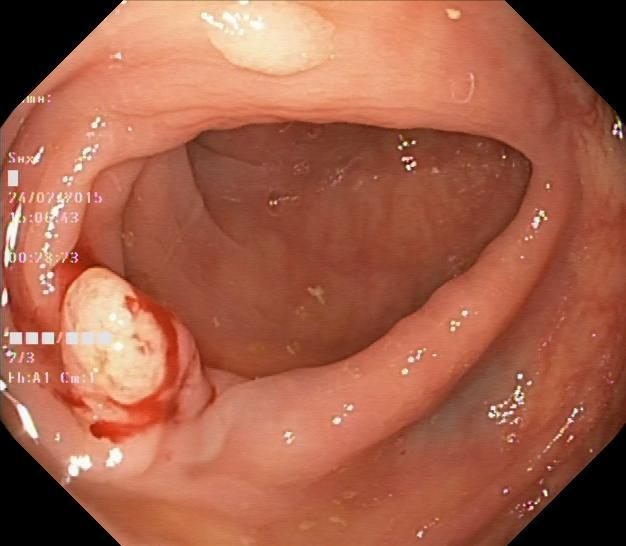


You are a medical expert. Use ONLY the evidence provided.

=== Evidence ===
in nearly half of the cases (45.7%). During our initial experience,we found polypoid lesions localised especially in the sigmoid colon that could be easily removed (Figure 4).No major adverse events were recorded, except for two cases of superficial “scratch-like” mucosal lesions of no clinical significance that occurred in the case of rigid colon due to inflammation (mild diverticulitis). CONCLUSION Prompt diagnosis of precancerous polyps during colo-noscopy is extremely important in order to reduce CRC rate, especially in asymptomatic patients. Dur-ing colonoscopy, the rate of colonic polyps missed varies from 6% to 27%'°!, It is known that the most effective way to estimate the adenoma miss rate, and consequently improve the ADR, is represented by the “back-to-back colonoscopy” technique performed in two consecutive same-day procedures in the same patient’. However, we cannot ignore this may dou-ble the pot

Evidence of multiple polyps observed, with Paris IIa morphology noted, consistent with a low-grade lesion.

### Retrieved Evidence:

in nearly half of the cases (45.7%). During our initial experience,we found polypoid lesions localised especially in the sigmoid colon that could be easily removed (Figure 4).No major adverse events were recorded, except for two cases of superficial “scratch-like” mucosal lesions of no clinical significance that occurred in the case of rigid colon due to inflammation (mild diverticulitis). CONCLUSION Prompt diagnosis of precancerous polyps during colo-noscopy is extremely important in order to reduce CRC rate, especially in asymptomatic patients. Dur-ing colonoscopy, the rate of colonic polyps missed varies from 6% to 27%'°!, It is known that the most effective way to estimate the adenoma miss rate, and consequently improve the ADR, is represented by the “back-to-back colonoscopy” technique performed in two consecutive same-day procedures in the same patient’. However, we cannot ignore this may dou-ble the potential complications, such as the risk of perforation. The first study of this method using EndoCuff
1 (10)Type of piles Internal 4 (40)External 6 (60)Type of polyps Adenomatous polyp 5 (50) Colon polyps 3 (30) Familial adenomatous polyposis 1 (10) Anal canal polyp 1 (10) Table 2. Clinicopathological characteristics of non-cancerous patients. n, number of patients. Another mechanism that miR-125 controls CRC development is through controlling signaling pathways. MiR-125 targeted fucosyltransferase 5 and fucosyltransferase 6 and altered the PI3K-AKT signaling pathway, which in turn affected CRC development”. The Hippo signaling system, which is critical for cancer cell invasion, regulates transcriptional co-activator with PDZ-binding motif (TAZ) and Yes-associated protein (YAP) by restricting their entry into the nucleus. By targeting TAZ, miR-125 suppress CRC proliferation and invasion”. Moreover, circ-RHOT1 sponges miR-326 that is poorly expressed and has suppressive functions in a variety of malignancies. Pyruvate dehydrogenase kinase 2 (PDK2) is essential for cancers glycolysis and promotes tumor (2023)
with at least one diminutive polyp, 7 (%) 45 (30.0%) 52 (34.7%) < 0.001Patients with at least one Paris type 0-IIa polyp, n (%) 39 (26.0%) 48 (32.0%) < 0.001Polyps detected, n 80 105 0.020Polyps detected, by dimension <6mm,7 69 91 < 0.001 > 6mm, 7 11 14 0.319Polyps detected, by type* 0-Ip, n 11 13 0.319 * Paris classification 2) Springer J Gastrointest Surg (2021) 25:2011-2018 Table 4 = Statistical results of false positives Al-assisted colonoscopy, n (%) False positive 52 (100.00)Submucosal tumor 4 (7.69)Cyst 1 (1.92)Feces 29 (55.77)Ulcer 4 (7.69)Mucosal fold 10 (19.23)Other (bubble, circular 4 (7.69) blood vessel, and so on) Compared with traditional colonoscopy, AJ-assisted colonos-copy showed a higher detection rate for 0-IIa polyps. This could be because most of the polyps were type O-IJa and because the sample size was not large enough. We found that the real-time polyp detection system yielded a total of 52 false positives, most of which were due to feces and mucosal folds. There were approximately
polyp 3 18.48 18.45 49,31 4,2 (2.78) 18.38 (7.11)(5.94, 57.5) (5.92, 57.5)Gastrointestinal disorders Large intestine 3 18.14 (5.83, 18.11 (5.81, 48.3 4.17 (2.75) 18.04 (6.98)perforation 56.45) 56.44)Skin and subcutaneous tissue disorders Acne 40 15.43 (11.27, 15.08 (11.02, 524.86 3.91 (3.46) 15.03 (11.56)21.13) 20.63)Gastrointestinal disorders Frequent bowel 17 15.38 (9.53, 15.23 (9.51, 225.42 3.92 (3.25) 15.18 (10.17)movements 24.82) 24.38)Eye disorders Retinal detachment 3 14.69 (4.72, 14.66 (4.7, 38.07 3.87 (2.45) 14.62 (5.66)45.68) 45.69)Gastrointestinal disorders Proctalgia 3 14.49 (4.66, 14.47 37.48 3.85 (2.43) 14.42 (5.58)45.06) (4.64, 45.1)Neoplasms benign, malignant and Colon cancer 4 12.77 (4.78, 12.74 (4.78, 43.15 3.67 (2.4) 12.7 (5.58)unspecified (incl cysts and polyps) 34.11) 33.95)Gastrointestinal disorders Diarrhoea 4 12.18 (4.56, 12.15 (4.56, 40.83 3.6 (2.33) 12.12 (5.33)haemorrhagic 32.53) 32.37)Metabolism and nutrition disorders Malnutrition 3 12.04 (3.87, 12.02 (3.86, 30.22 3.58 (2.17)
disease Perianal involvement (CD),  (%) Fistula Abscess Fissure Extraintestinal manifestations, n (%)Family history, 1 (%) History of gastrointestinal surgery, n (%)History of perianal surgery, n (%) Medication use within 6 mo before diagnosis, n (%) Yao LY et al. Medication trends for IBD The classification of body mass index: Underweight: < 18.5; Normal: 18.5-23.9; Overweight: 24-28; Obese > 28. Disease behavior was not available in 1407patients. IOR: Interquartile ranges; BMI: Body mass index; CDAI: Crohn’s disease Activity Index; CD: Crohn’s Disease. Baishideng® WJG | https://www.wjgnet.com 4109 igated potential factors impacting initial drug strategies. Table 3 presents factors for commencing different medications compared with a no prescription group among patients with CD. Specifically, variables including urban living, L3, B3, gastrointestinal surgical history, and diagnosis after 2009 yielded the most significant predictors of patients not commencing CS for initial treatment strategies. However,

In [86]:
from IPython.display import display, Markdown, Image
import os
import gc

torch.manual_seed(27603)

question="""
Are there any abnormalities, e.g polyps,  in the image, and how would you grade its severity? Describe the characteristics of the abnormalities and provide relevant clinical recommendations based on established medical guidelines.

"""
img = "/home/qzhao9/datasets/Kvasir-VQA-x1/images/cl8k2u1pu1e37083257oa5xt6.jpg"
# Display the image using IPython.display
if os.path.exists(img):
    display(Image(filename=img,width=400, height=400))
else:
    display(Markdown(f"Image not found: {img}"))
# print(os.path.exists(img))
# print(pico_query(img, question))
answer,evidence = medical_rag_qa(img,question,'v2')
# clear GPU cache
torch.cuda.empty_cache()
gc.collect()

display(Markdown(answer))

display(Markdown("### Retrieved Evidence:"))
display(Markdown(evidence))

v0: vidence of a Paris IIa polyp is present, consistent with a Paris classification system.

v1: Evidence of a small polyp noted in the colon, consistent with Paris IIa classification, and no other significant findings observed.

v2: Evidence of multiple polyps observed, with Paris IIa morphology noted, consistent with a low-grade lesion.